# PV Filter Debug Notebook
Step-by-step walkthrough with diagnostics.

**Pipeline:** Clear-sky (raw irr, clipped to 1500 W/m²) → Normalize → Low irr/power → IQR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '.')
sys.path.insert(0, 'page_supporting_files')
from page_supporting_files.pvcopilot_filter_functions import identify_outliers_iqr, clear_sky_filter, detect_clear_days
from page_supporting_files.analysis_utils import normalize, low_irra_power_filter
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')

Imports OK


## 0 · Load & inspect data

In [2]:
df_raw = pd.read_parquet('data/sys_1422_downsampled.parquet')
if not isinstance(df_raw.index, pd.DatetimeIndex):
    df_raw.index = pd.to_datetime(df_raw.index)
print(f'Shape: {df_raw.shape}  |  {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Columns: {df_raw.columns.tolist()}')
print()
print(df_raw.describe().round(2))

Shape: (15207, 3)  |  2016-05-05 09:00:00 → 2018-01-28 23:00:00
Columns: ['poa_irradiance', 'module_temperature_C', 'dc_power_inv1']

       poa_irradiance  module_temperature_C  dc_power_inv1
count        13851.00              13851.00       13851.00
mean           168.05                135.46         418.14
std            404.04                454.91         739.79
min            -10.82               -167.85          -0.71
25%             -0.93                 -0.00           0.01
50%              3.40                 11.16           3.57
75%            197.28                 23.89         450.55
max          34047.96               1802.61        5367.72


In [3]:
POWER_KEY = None; IRR_KEY = None; TEMP_KEY = None
for c in df_raw.columns:
    cl = c.lower()
    if POWER_KEY is None and any(k in cl for k in ['power','pmp','p_mp','watt','dc_pow']): POWER_KEY = c
    if IRR_KEY   is None and any(k in cl for k in ['irr','poa','ghi','rad']): IRR_KEY = c
    if TEMP_KEY  is None and any(k in cl for k in ['temp','module_t','t_mod']): TEMP_KEY = c
print(f'Power={POWER_KEY}  Irr={IRR_KEY}  Temp={TEMP_KEY}')
mapped_variables_dict = {'DC Power': POWER_KEY, 'Irradiance': IRR_KEY, 'Module temperature': TEMP_KEY}
assert POWER_KEY and IRR_KEY and TEMP_KEY, 'Set column names manually'

n_days = df_raw.index.normalize().nunique()
ppd = len(df_raw) / n_days
print(f'\nDates={n_days}  pts/day={ppd:.1f}  mode={"sub-daily" if ppd>=4 else "coarse"}')
print(f'\n⚠  Sensor sanity check:')
print(f'  Irradiance  max={df_raw[IRR_KEY].max():.1f} W/m²   (expect ≤1200)')
print(f'  Temperature max={df_raw[TEMP_KEY].max():.1f} °C     (expect ≤80)')
print(f'  Irr > 1500 W/m²: {(df_raw[IRR_KEY]>1500).sum()} pts  ← clipped before smoothness scoring')

Power=dc_power_inv1  Irr=poa_irradiance  Temp=module_temperature_C

Dates=634  pts/day=24.0  mode=sub-daily

⚠  Sensor sanity check:
  Irradiance  max=34048.0 W/m²   (expect ≤1200)
  Temperature max=1802.6 °C     (expect ≤80)
  Irr > 1500 W/m²: 3 pts  ← clipped before smoothness scoring


---
## 1 · Clear-sky filter — deep diagnostics

Root cause of previous failure: `poa_irradiance` had max=34047 W/m² (sensor fault).
Using `max()` to normalize smoothness scores meant ALL days scored ≈ 0.
**Fix:** clip to 1500 W/m² and use 95th percentile (not max) as the normalization reference.

In [4]:
IRR_MAX_PHYSICAL = 1500.0
irr_clipped = df_raw[IRR_KEY].clip(lower=0, upper=IRR_MAX_PHYSICAL)

# Build per-day groups
date_groups = {}
for ts, val in irr_clipped.items():
    date_groups.setdefault(ts.date(), []).append(val)
unique_dates = sorted(date_groups.keys())
n_days = len(unique_dates)

smoothness_raw = np.full(n_days, np.nan)
energy_raw = np.zeros(n_days)
for i, d in enumerate(unique_dates):
    v = np.array(date_groups[d], dtype=float)
    energy_raw[i] = np.nansum(v)
    if len(v) >= 3:
        d2 = v[:-2] - 2*v[1:-1] + v[2:]
        smoothness_raw[i] = np.sum(np.abs(d2))

# Energy score
es = pd.Series(energy_raw, index=pd.to_datetime(unique_dates))
r90 = es.rolling(61, center=True, min_periods=3).quantile(0.90).ffill().bfill().replace(0, np.nan)
energy_score = np.clip(es.values / r90.values, 0, 1)

# Smoothness score — 95th pct ref
valid = smoothness_raw[~np.isnan(smoothness_raw)]
ref_smooth = np.percentile(valid, 95) if len(valid) else 1.0
ref_smooth = ref_smooth if ref_smooth > 0 else 1.0
smoothness_score = np.clip(1.0 - smoothness_raw / ref_smooth, 0, 1)
smoothness_score = np.where(np.isnan(smoothness_raw), 0.0, smoothness_score)

print(f'ref_smooth (95th pct L1-norm): {ref_smooth:.1f}')
print()
print('ENERGY SCORE')
for t in [0.9, 0.8, 0.7, 0.6, 0.5]:
    print(f'  >= {t}: {(energy_score>=t).mean()*100:.1f}% of days')
print()
print('SMOOTHNESS SCORE')
for t in [0.9, 0.8, 0.7, 0.6, 0.5]:
    print(f'  >= {t}: {(smoothness_score>=t).mean()*100:.1f}% of days')
print()
print('JOINT (AND rule) — days × pts retained')
for se in [0.8, 0.7, 0.6]:
    for ss in [0.9, 0.8, 0.7, 0.6]:
        mask = (smoothness_score>=ss) & (energy_score>=se)
        clear_d = set(d for d,c in zip(unique_dates, mask) if c)
        pts = sum(1 for ts in df_raw.index if ts.date() in clear_d)
        print(f'  energy>={se}, smooth>={ss}: {mask.sum():3d} days  {pts:5,} pts ({pts/len(df_raw)*100:.1f}%)')

ref_smooth (95th pct L1-norm): 2967.5

ENERGY SCORE
  >= 0.9: 23.5% of days
  >= 0.8: 33.0% of days
  >= 0.7: 40.9% of days
  >= 0.6: 47.3% of days
  >= 0.5: 52.8% of days

SMOOTHNESS SCORE
  >= 0.9: 8.8% of days
  >= 0.8: 15.9% of days
  >= 0.7: 21.8% of days
  >= 0.6: 38.6% of days
  >= 0.5: 51.4% of days

JOINT (AND rule) — days × pts retained
  energy>=0.8, smooth>=0.9:   0 days      0 pts (0.0%)
  energy>=0.8, smooth>=0.8:   0 days      0 pts (0.0%)
  energy>=0.8, smooth>=0.7:   4 days     96 pts (0.6%)
  energy>=0.8, smooth>=0.6:  72 days  1,728 pts (11.4%)
  energy>=0.7, smooth>=0.9:   0 days      0 pts (0.0%)
  energy>=0.7, smooth>=0.8:   0 days      0 pts (0.0%)
  energy>=0.7, smooth>=0.7:   4 days     96 pts (0.6%)
  energy>=0.7, smooth>=0.6:  72 days  1,728 pts (11.4%)
  energy>=0.6, smooth>=0.9:   0 days      0 pts (0.0%)
  energy>=0.6, smooth>=0.8:   0 days      0 pts (0.0%)
  energy>=0.6, smooth>=0.7:   4 days     96 pts (0.6%)
  energy>=0.6, smooth>=0.6:  73 days  1,752 

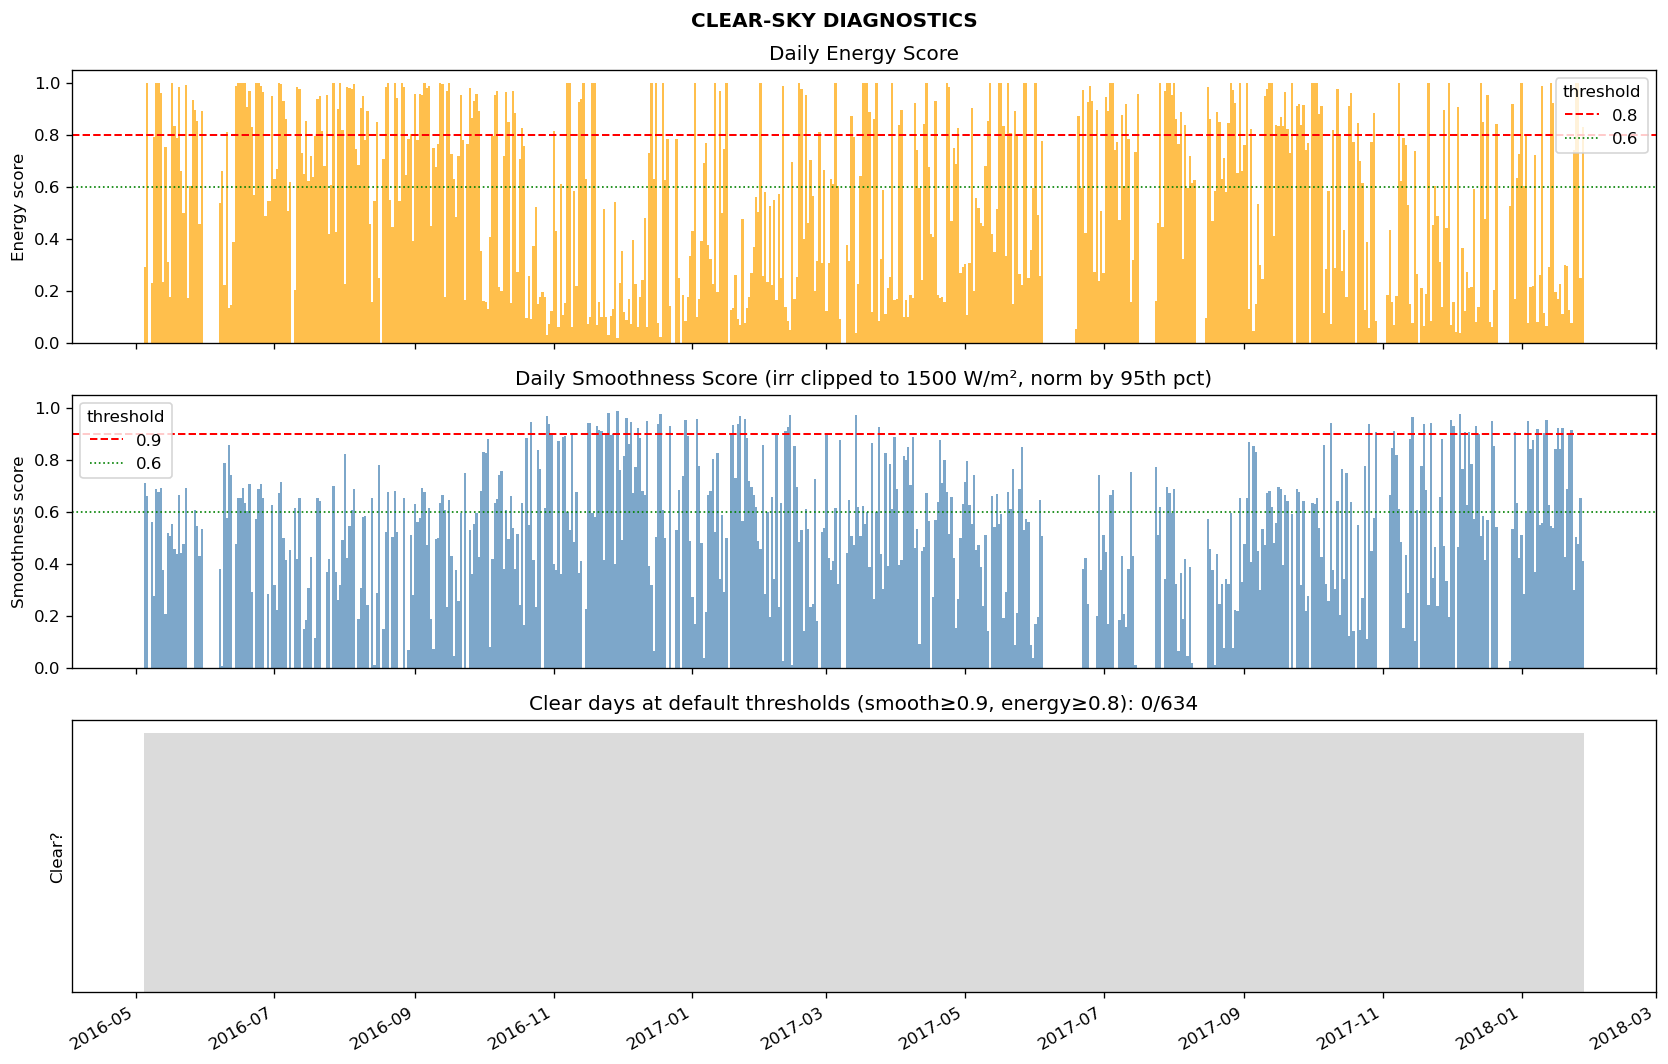

In [5]:
date_idx = pd.to_datetime(unique_dates)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(date_idx, energy_score, width=1, color='orange', alpha=0.7)
axes[0].axhline(0.8, color='red', lw=1.2, ls='--', label='0.8')
axes[0].axhline(0.6, color='green', lw=1, ls=':', label='0.6')
axes[0].set_ylabel('Energy score'); axes[0].set_ylim(0,1.05)
axes[0].set_title('Daily Energy Score'); axes[0].legend(title='threshold')

axes[1].bar(date_idx, smoothness_score, width=1, color='steelblue', alpha=0.7)
axes[1].axhline(0.9, color='red', lw=1.2, ls='--', label='0.9')
axes[1].axhline(0.6, color='green', lw=1, ls=':', label='0.6')
axes[1].set_ylabel('Smoothness score'); axes[1].set_ylim(0,1.05)
axes[1].set_title('Daily Smoothness Score (irr clipped to 1500 W/m², norm by 95th pct)')
axes[1].legend(title='threshold')

joint = (smoothness_score >= 0.9) & (energy_score >= 0.8)
axes[2].bar(date_idx, np.ones(n_days), width=1,
            color=['green' if c else 'lightgray' for c in joint], alpha=0.8)
axes[2].set_yticks([]); axes[2].set_ylabel('Clear?')
axes[2].set_title(f'Clear days at default thresholds (smooth≥0.9, energy≥0.8): {joint.sum()}/{n_days}')

fig.autofmt_xdate()
plt.suptitle('CLEAR-SKY DIAGNOSTICS', fontweight='bold')
plt.tight_layout(); plt.show()

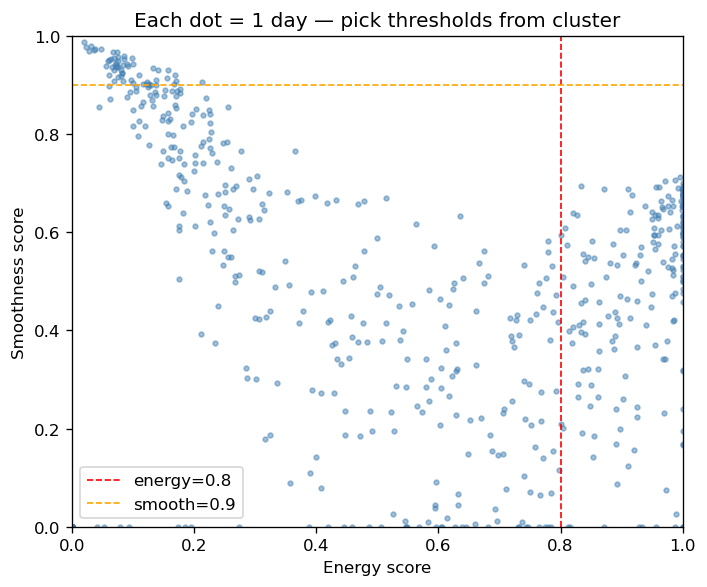

In [6]:
# Scatter: energy vs smoothness — helps choose thresholds visually
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(energy_score, smoothness_score, s=8, alpha=0.5, color='steelblue')
ax.axvline(0.8, color='red', lw=1, ls='--', label='energy=0.8')
ax.axhline(0.9, color='orange', lw=1, ls='--', label='smooth=0.9')
ax.set_xlabel('Energy score'); ax.set_ylabel('Smoothness score')
ax.set_title('Each dot = 1 day — pick thresholds from cluster')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()

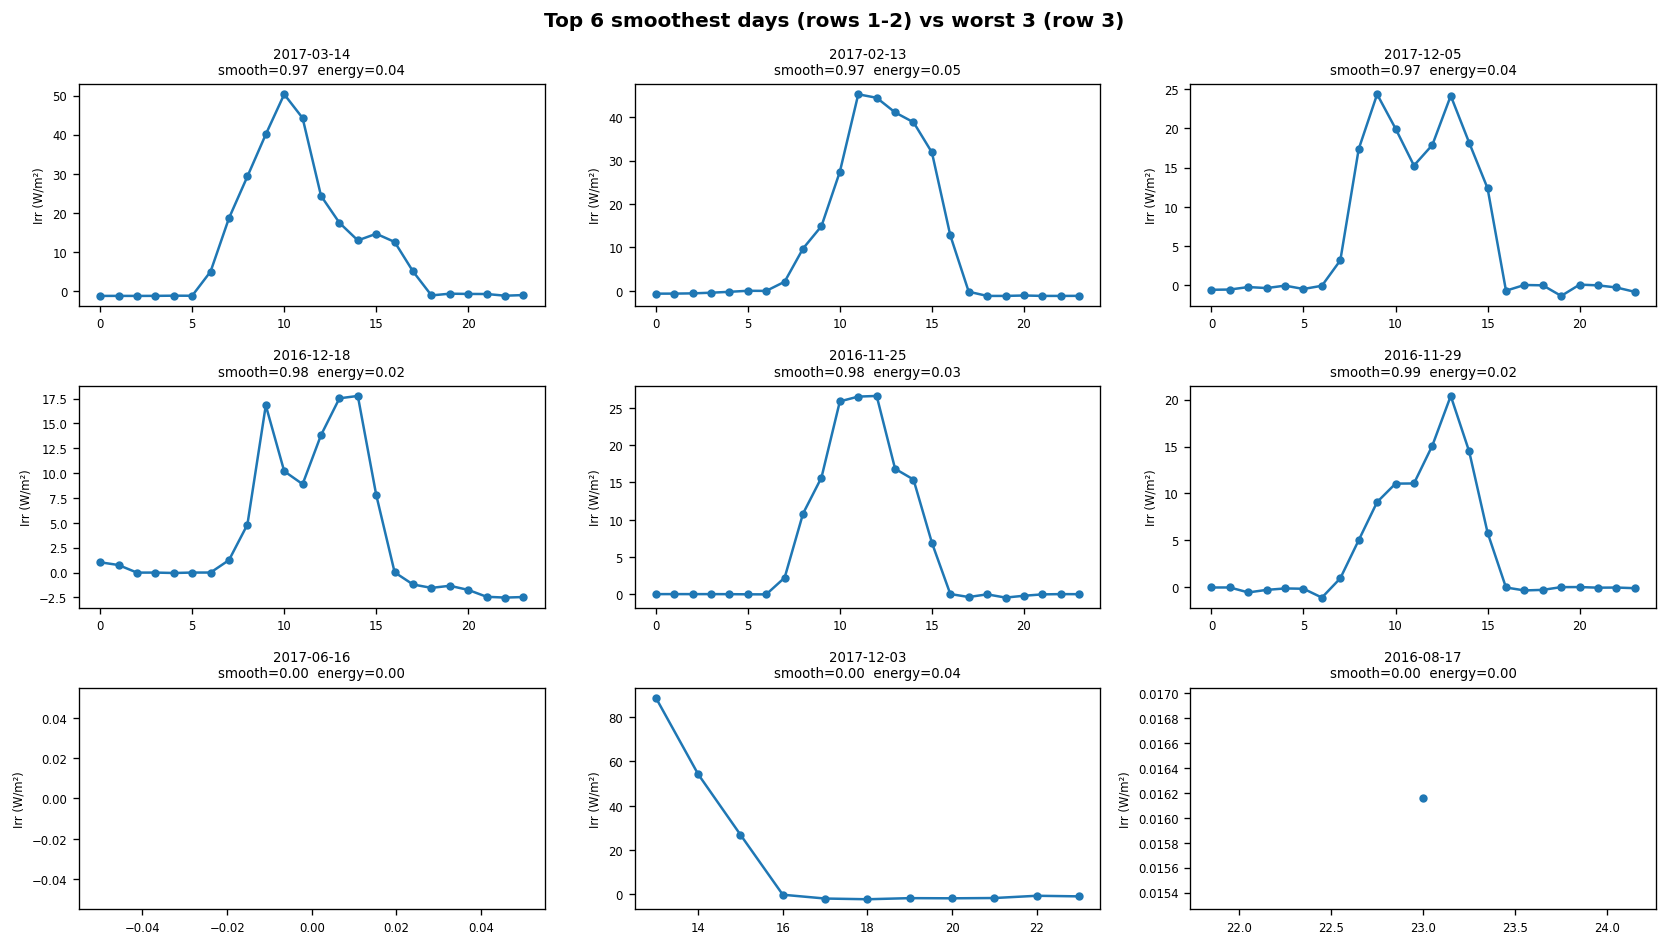

In [7]:
# Show intraday irradiance profiles for best/worst smooth days
top6 = np.argsort(smoothness_score)[-6:]
bot3 = np.argsort(smoothness_score)[:3]

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()
for ax_i, d_i in enumerate(list(top6) + list(bot3)):
    d = unique_dates[d_i]
    day_data = df_raw[df_raw.index.date == d][IRR_KEY]
    axes[ax_i].plot(day_data.values, marker='o', ms=4)
    axes[ax_i].set_title(f'{d}\nsmooth={smoothness_score[d_i]:.2f}  energy={energy_score[d_i]:.2f}', fontsize=8)
    axes[ax_i].set_ylabel('Irr (W/m²)', fontsize=7); axes[ax_i].tick_params(labelsize=7)
plt.suptitle('Top 6 smoothest days (rows 1-2) vs worst 3 (row 3)', fontweight='bold')
plt.tight_layout(); plt.show()

[clear_sky_filter] mode=sub-daily, clear_days=228/634
Thresholds: smooth>=0.3, energy>=0.5
Before : 15,207   After: 5,472  (36.0% retained)


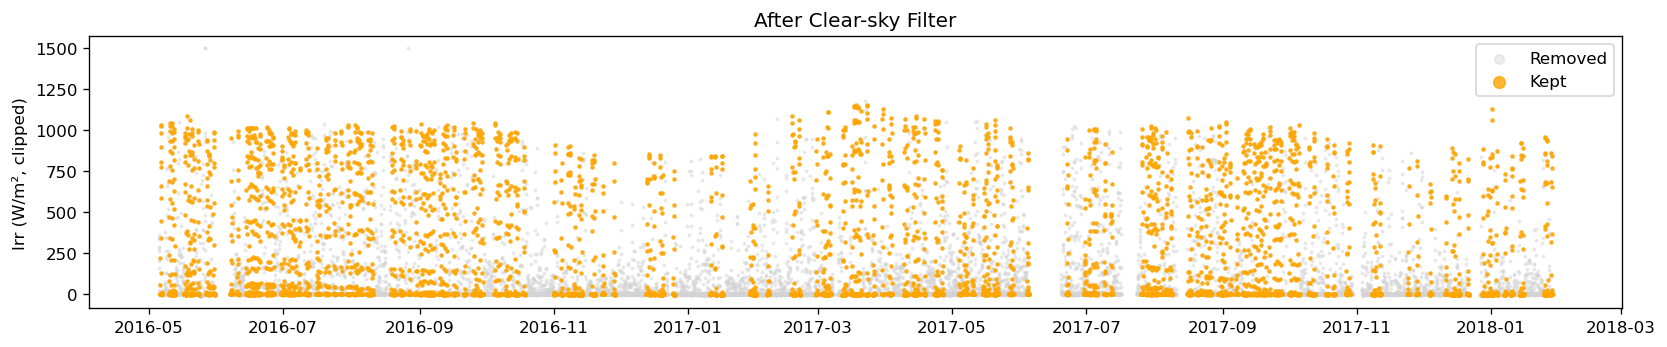

In [11]:
# ── CHOOSE & APPLY ────────────────────────────────────────────────────────
SMOOTH_THRESH = 0.3   # <-- adjust based on plots above
ENERGY_THRESH = 0.5   # <-- adjust

cs_normal, cs_outlier = clear_sky_filter(df_raw, IRR_KEY,
    smoothness_threshold=SMOOTH_THRESH, energy_threshold=ENERGY_THRESH)
df_after_cs = df_raw.loc[cs_normal].copy()

print(f'Thresholds: smooth>={SMOOTH_THRESH}, energy>={ENERGY_THRESH}')
print(f'Before : {len(df_raw):,}   After: {len(df_after_cs):,}  ({len(df_after_cs)/len(df_raw)*100:.1f}% retained)')

fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(df_raw.index, df_raw[IRR_KEY].clip(upper=1500), s=2, color='lightgray', alpha=0.4, label='Removed')
ax.scatter(df_after_cs.index, df_after_cs[IRR_KEY].clip(upper=1500), s=3, color='orange', alpha=0.8, label='Kept')
ax.set_ylabel('Irr (W/m², clipped)'); ax.set_title('After Clear-sky Filter')
ax.legend(markerscale=4); plt.tight_layout(); plt.show()

---
## 2 · Normalize

norm stats:
count    2500.000
mean     2365.869
std      1098.707
min      -688.044
25%      2539.774
50%      2859.916
75%      2960.583
max      4181.275
Name: norm, dtype: float64


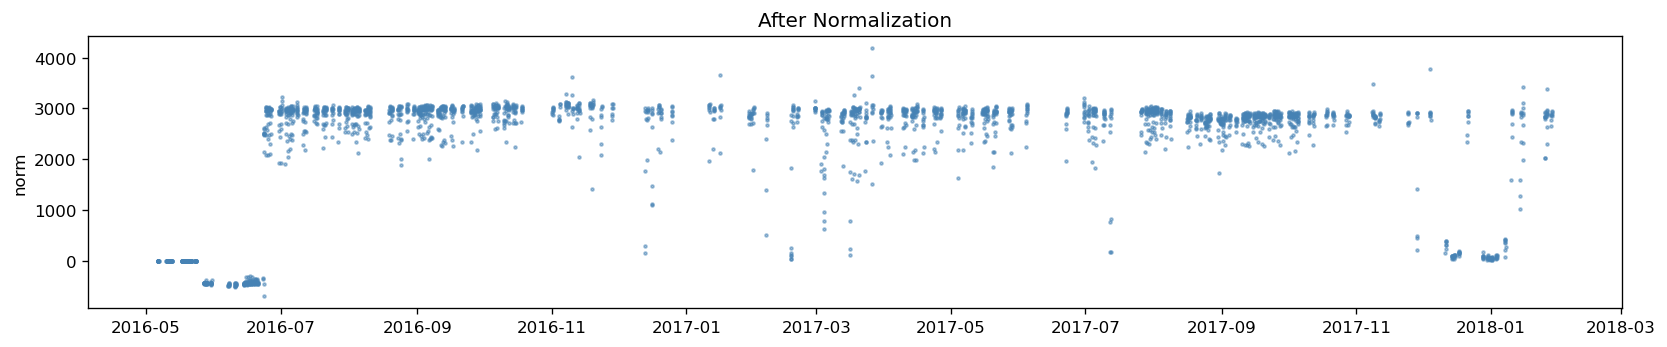

In [12]:
GAMMA = -0.004
df_norm = normalize(df_after_cs.copy(), mapped_variables_dict, gamma=GAMMA)
print('norm stats:'); print(df_norm['norm'].describe().round(3))
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(df_norm.index, df_norm['norm'], s=3, alpha=0.5, color='steelblue')
ax.set_ylabel('norm'); ax.set_title('After Normalization'); plt.tight_layout(); plt.show()

---
## 3 · Low irradiance / power filter

Before: 5,472   After: 1,626  (29.7%)
  ① Irr > 300      : 33.8%
  ② Power > 0.02×G : 84.0%
  ③ Norm [0.01,3113.81] : 40.0%
  AND                   : 29.7%


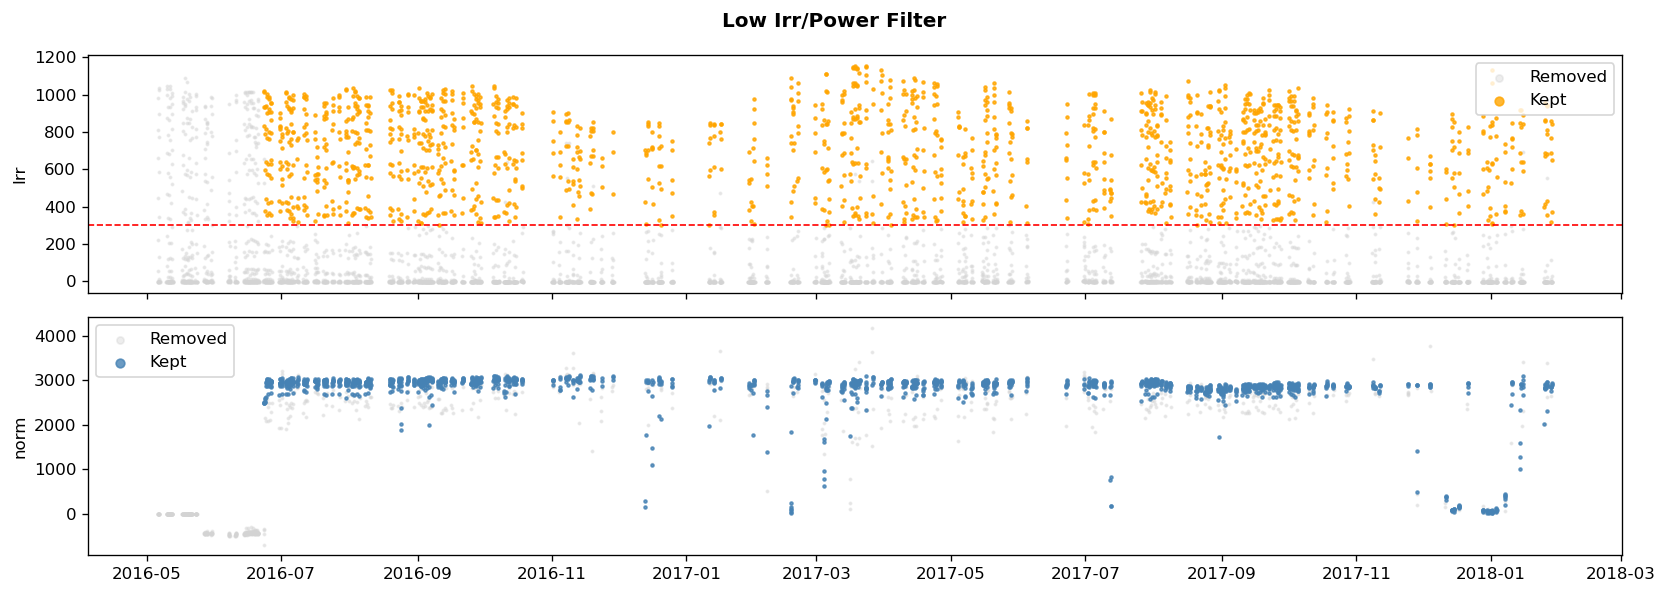

In [13]:
IRR_THRESH=300; POWER_RATIO=0.02; NORM_LOWER=0.01; NORM_UPPER_PCT=99
normal_lip, outlier_lip = low_irra_power_filter(df_norm, mapped_variables_dict,
    irr_thresh=IRR_THRESH, power_ratio=POWER_RATIO, norm_lower=NORM_LOWER, norm_upper_pct=NORM_UPPER_PCT)
df_after_lip = df_norm.loc[normal_lip].copy()

mask_irr  = df_norm[IRR_KEY] > IRR_THRESH
mask_pow  = df_norm[POWER_KEY] > POWER_RATIO * df_norm[IRR_KEY]
norm_upper = df_norm['norm'].quantile(NORM_UPPER_PCT/100)
mask_norm = df_norm['norm'].between(NORM_LOWER, norm_upper)

print(f'Before: {len(df_norm):,}   After: {len(df_after_lip):,}  ({len(df_after_lip)/max(len(df_norm),1)*100:.1f}%)')
print(f'  ① Irr > {IRR_THRESH}      : {mask_irr.mean()*100:.1f}%')
print(f'  ② Power > {POWER_RATIO}×G : {mask_pow.mean()*100:.1f}%')
print(f'  ③ Norm [{NORM_LOWER},{norm_upper:.2f}] : {mask_norm.mean()*100:.1f}%')
print(f'  AND                   : {(mask_irr&mask_pow&mask_norm).mean()*100:.1f}%')

fig, axes = plt.subplots(2,1,figsize=(14,5),sharex=True)
axes[0].scatter(df_norm.loc[outlier_lip].index, df_norm.loc[outlier_lip][IRR_KEY], s=2, color='lightgray', alpha=0.4, label='Removed')
axes[0].scatter(df_after_lip.index, df_after_lip[IRR_KEY], s=3, color='orange', alpha=0.8, label='Kept')
axes[0].axhline(IRR_THRESH, color='red', lw=1, ls='--'); axes[0].set_ylabel('Irr'); axes[0].legend(markerscale=3)
axes[1].scatter(df_norm.loc[outlier_lip].index, df_norm.loc[outlier_lip]['norm'], s=2, color='lightgray', alpha=0.4, label='Removed')
axes[1].scatter(df_after_lip.index, df_after_lip['norm'], s=3, color='steelblue', alpha=0.8, label='Kept')
axes[1].set_ylabel('norm'); axes[1].legend(markerscale=3)
plt.suptitle('Low Irr/Power Filter', fontweight='bold'); plt.tight_layout(); plt.show()

---
## 4 · IQR Outlier Removal


--- Outlier Detection Metrics for 'norm' ---
Q1 (25th percentile): 2835.42
Q3 (75th percentile): 2982.06
IQR: 146.63
Lower Bound: 2615.47
Upper Bound: 3202.01
---------------------------------------------------

Bounds=[2615.469, 3202.009]   Before:1,626  After:1,501  Removed:125


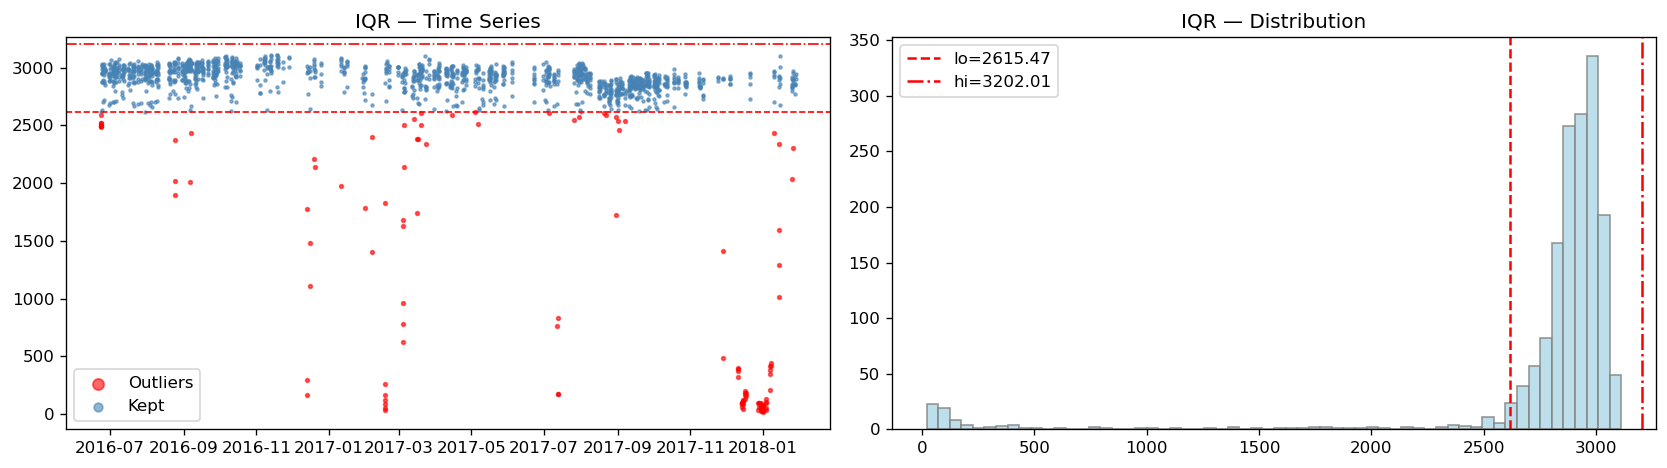

In [14]:
IQR_MULT = 1.5
normal_iqr, outlier_iqr = identify_outliers_iqr(df_after_lip, 'norm', iqr_multiplier=IQR_MULT)
df_final = df_after_lip.loc[normal_iqr].copy()
Q1=df_after_lip['norm'].quantile(0.25); Q3=df_after_lip['norm'].quantile(0.75)
IQR=Q3-Q1; lo=Q1-IQR_MULT*IQR; hi=Q3+IQR_MULT*IQR
print(f'Bounds=[{lo:.3f}, {hi:.3f}]   Before:{len(df_after_lip):,}  After:{len(df_final):,}  Removed:{len(outlier_iqr):,}')

fig, axes = plt.subplots(1,2,figsize=(14,4))
axes[0].scatter(df_after_lip.loc[outlier_iqr].index, df_after_lip.loc[outlier_iqr]['norm'], s=5, color='red', alpha=0.6, label='Outliers')
axes[0].scatter(df_final.index, df_final['norm'], s=3, color='steelblue', alpha=0.6, label='Kept')
axes[0].axhline(lo, color='red', lw=1, ls='--'); axes[0].axhline(hi, color='red', lw=1, ls='-.')
axes[0].set_title('IQR — Time Series'); axes[0].legend(markerscale=3)
axes[1].hist(df_after_lip['norm'].dropna(), bins=60, color='lightblue', edgecolor='gray', alpha=0.8)
axes[1].axvline(lo, color='red', lw=1.5, ls='--', label=f'lo={lo:.2f}')
axes[1].axvline(hi, color='red', lw=1.5, ls='-.', label=f'hi={hi:.2f}')
axes[1].set_title('IQR — Distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 5 · Summary

Step                         Points  Retained
Raw data                     15,207    100.0%
After clear-sky               5,472     36.0%
After low irr/power           1,626     10.7%
After IQR                     1,501      9.9%


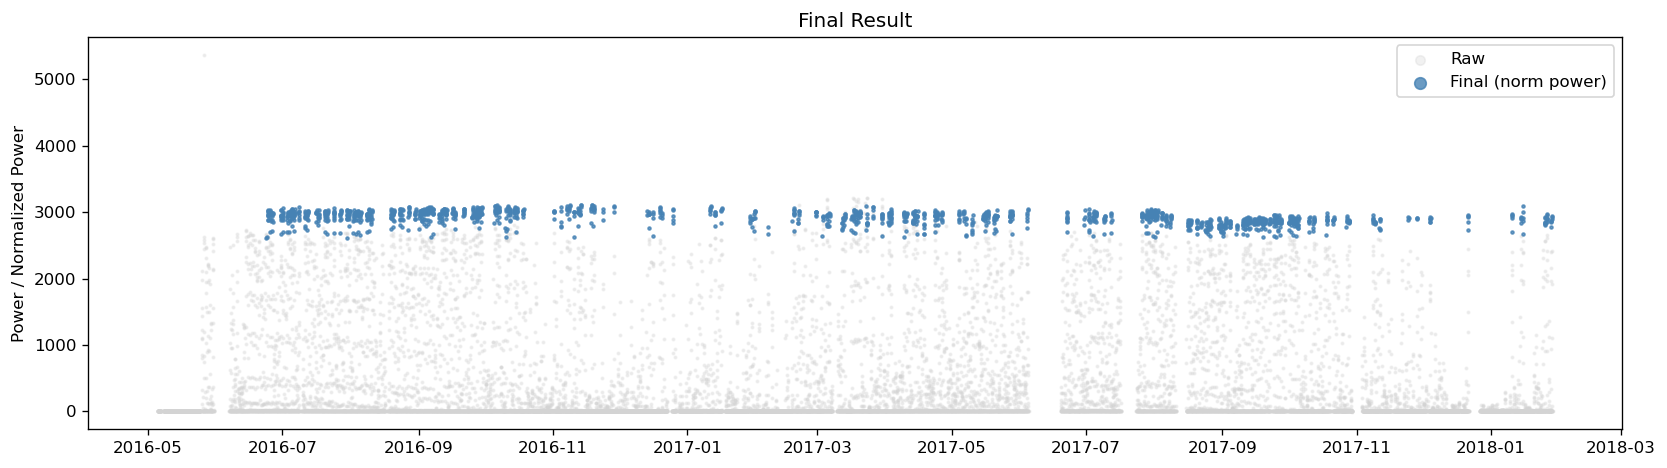

In [15]:
n0,n1,n2,n3=len(df_raw),len(df_after_cs),len(df_after_lip),len(df_final)
print('='*52)
print(f'{"Step":<26} {"Points":>8}  {"Retained":>8}')
print('='*52)
for label, n in [('Raw data',n0),('After clear-sky',n1),('After low irr/power',n2),('After IQR',n3)]:
    print(f'{label:<26} {n:>8,}  {n/n0*100:>7.1f}%')
print('='*52)

fig, ax = plt.subplots(figsize=(14,4))
ax.scatter(df_raw.index, df_raw[POWER_KEY], s=2, color='lightgray', alpha=0.3, label='Raw')
ax.scatter(df_final.index, df_final['norm'], s=3, color='steelblue', alpha=0.8, label='Final (norm power)')
ax.set_ylabel('Power / Normalized Power'); ax.set_title('Final Result')
ax.legend(markerscale=4); plt.tight_layout(); plt.show()